<a href="https://colab.research.google.com/github/Sindhu-Bhukya-676/NASSCOM/blob/main/WEEK%203/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [44]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [45]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [46]:
import pandas as pd
import seaborn as sns

# Load sample dataset (Seaborn's 'tips' dataset)
df = sns.load_dataset("tips")

# 1. Numerical vs categorical columns
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = df.select_dtypes(include=["category", "object"]).columns.tolist()

print("1. Numerical Columns:", num_cols)
print("   Categorical Columns:", cat_cols)

# 2. Mean of a numerical column (tip)
mean_tip = df["tip"].mean()
print(f"\n2. Mean tip amount: ${mean_tip:.2f}")

# 3. Value counts of a categorical column (sex)
sex_value_counts = df["sex"].value_counts()
print("\n3. Value counts for 'sex':")
print(sex_value_counts)

1. Numerical Columns: ['total_bill', 'tip', 'size']
   Categorical Columns: ['sex', 'smoker', 'day', 'time']

2. Mean tip amount: $3.00

3. Value counts for 'sex':
sex
Male      157
Female     87
Name: count, dtype: int64


In [47]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


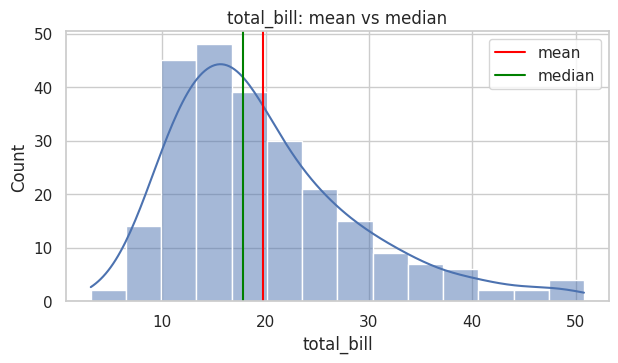

In [48]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

1. Mean:   $3.00
   Median: $2.90
   Mode:   $2.00

2. Is mean > median? True
   -> The distribution is right-skewed (positively skewed) due to high tip outliers.


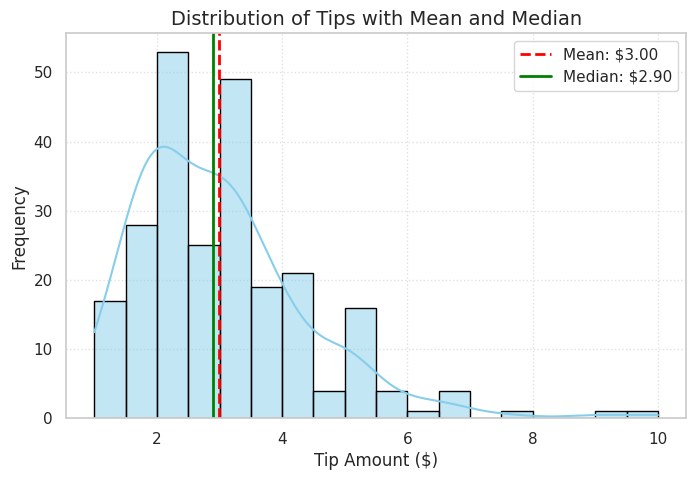

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load tips dataset
df = sns.load_dataset("tips")
tip = df["tip"]

# 1. mean, median, mode
mean_val = tip.mean()
median_val = tip.median()
mode_val = tip.mode()[0]  # mode() returns a Series

print(f"1. Mean:   ${mean_val:.2f}")
print(f"   Median: ${median_val:.2f}")
print(f"   Mode:   ${mode_val:.2f}")

# 2. mean > median ?
is_right_skewed = mean_val > median_val
print(f"\n2. Is mean > median? {is_right_skewed}")
if is_right_skewed:
    print(
        "   -> The distribution is right-skewed (positively skewed) due to high tip outliers."
    )

# 3. histogram with mean & median lines
plt.figure(figsize=(8, 5))
sns.histplot(tip, kde=True, color="skyblue", edgecolor="black")

# Add vertical lines for mean and median
plt.axvline(
    mean_val,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_val:.2f}",
)
plt.axvline(
    median_val,
    color="green",
    linestyle="-",
    linewidth=2,
    label=f"Median: ${median_val:.2f}",
)

plt.title("Distribution of Tips with Mean and Median", fontsize=14)
plt.xlabel("Tip Amount ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [50]:
l = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)



Range : 47.74
Var   : 79.25
Std   : 8.9


In [51]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')


Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [52]:
import pandas as pd
import seaborn as sns

# Load tips dataset
df = sns.load_dataset("tips")
tip = df["tip"]

# 1. range, variance, std
tip_range = tip.max() - tip.min()
tip_var = tip.var()
tip_std = tip.std()

print(f"1. Range:              ${tip_range:.2f}")
print(f"   Sample Variance:    {tip_var:.4f}")
print(f"   Standard Deviation: ${tip_std:.2f}")

# 2. Q1, Q3, IQR
q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)
iqr = q3 - q1

print(f"\n2. Q1 (25th percentile): ${q1:.2f}")
print(f"   Q3 (75th percentile): ${q3:.2f}")
print(f"   IQR:                  ${iqr:.2f}")

# 3. Most robust measure of spread = Interquartile Range (IQR)
robust_measure = "Interquartile Range (IQR)"
print(f"\n3. Most robust measure of spread = {robust_measure}")

1. Range:              $9.00
   Sample Variance:    1.9145
   Standard Deviation: $1.38

2. Q1 (25th percentile): $2.00
   Q3 (75th percentile): $3.56
   IQR:                  $1.56

3. Most robust measure of spread = Interquartile Range (IQR)


In [53]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


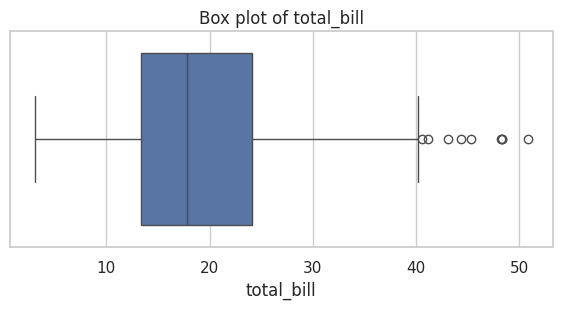

In [54]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


1. Five-Number Summary:
   Min    : $1.00
   Q1     : $2.00
   Median : $2.90
   Q3     : $3.56
   Max    : $10.00

2. Skewness: 1.4655
   -> Positive skewness (> 0): The distribution leans to the left, with a long tail stretching to the right (right-skewed).


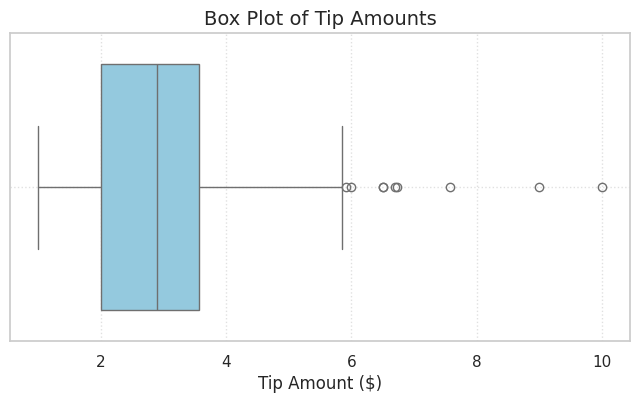

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load tips dataset
df = sns.load_dataset("tips")
tip = df["tip"]

# 1. five-number summary
five_num = {
    "Min": tip.min(),
    "Q1": tip.quantile(0.25),
    "Median": tip.median(),
    "Q3": tip.quantile(0.75),
    "Max": tip.max(),
}

print("1. Five-Number Summary:")
for key, val in five_num.items():
    print(f"   {key:<7}: ${val:.2f}")

# 2. skewness (+ comment on the direction of the lean)
skew_val = tip.skew()
print(f"\n2. Skewness: {skew_val:.4f}")

if skew_val > 0:
    print(
        "   -> Positive skewness (> 0): The distribution leans to the left, with a long tail stretching to the right (right-skewed)."
    )
elif skew_val < 0:
    print(
        "   -> Negative skewness (< 0): The distribution leans to the right, with a long tail stretching to the left (left-skewed)."
    )
else:
    print("   -> Skewness is 0: The distribution is symmetric.")

# 3. box plot of tip
plt.figure(figsize=(8, 4))
sns.boxplot(x=tip, color="skyblue")

plt.title("Box Plot of Tip Amounts", fontsize=14)
plt.xlabel("Tip Amount ($)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

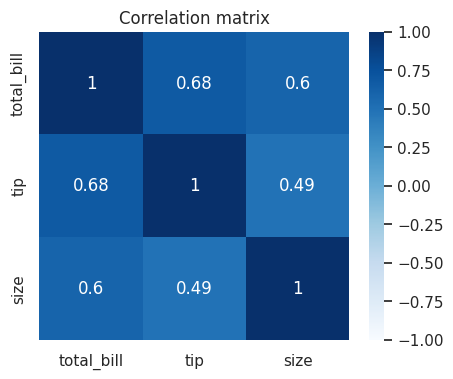

In [57]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()



In [58]:
df.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


1. Rounded Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


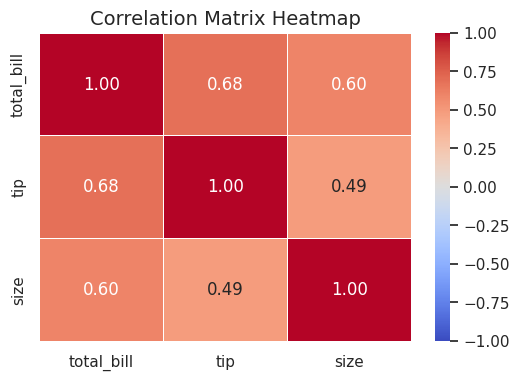


3. Summary Statistics (df.describe()):
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
df = sns.load_dataset("tips")

# 1. correlation matrix (rounded)
corr_matrix = df.corr(numeric_only=True).round(2)
print("1. Rounded Correlation Matrix:")
print(corr_matrix)

# 2. heatmap of the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.show()

# 3. df.describe() + 3 insights as comments
print("\n3. Summary Statistics (df.describe()):")
print(df.describe())

# Insight 1: 'total_bill' and 'tip' have a strong positive correlation (~0.68), showing that customers generally tip higher amounts on larger bills.
# Insight 2: Party 'size' positively correlates with both 'total_bill' (0.60) and 'tip' (0.49), meaning larger dining groups spend and tip more overall.
# Insight 3: The average total bill is $19.79 with a standard deviation of $8.90, and 75% of bills are $24.12 or less, showing that most transactions cluster in the lower-to-mid price range with a few high-value outliers up to $50.81.